# Yelp — Разведочный анализ среза (EDA_2)
### Групповой проект №5 · Deep Learning · НИУ ВШЭ БИ

**Платформа:** Yelp — сервис отзывов о заведениях. Один датасет (Yelp Open Dataset),
две **содержательно связанные** бизнес-задачи, под которые и затачивается этот EDA:

| | Задача 1 — Рекомендации | Задача 2 — Анализ отзывов |
|---|---|---|
| **Природа данных** | табличные (user × business) | текст отзывов |
| **Архитектура (DL)** | полносвязные сети: MF → MLP → NeuMF | RNN/CNN/Transformer: BiLSTM → TextCNN → DistilBERT |
| **Таргет** | `stars` (1–5), которые юзер поставит заведению | тональность по `stars`; аспекты; расхождение текст↔оценка |
| **Что смотрим в EDA** | распределение оценок, активность юзеров, популярность мест, разреженность матрицы, фичи и смещения | длина текста, баланс классов, словарь, отличительные слова, аспекты, фейк-сигналы, язык |

**Цель EDA** — не просто «посмотреть на данные», а извлечь решения для каждого этапа моделирования:
как кодировать признаки, чем обусловлен выбор архитектур, какие ловушки (cold-start, дисбаланс
классов, разреженность, не-английский текст) надо обработать на препроцессинге.

> Выбор городов-среза обоснован в `EDA_1.ipynb`. Данные подготовлены скриптами `download.py`
> (Kaggle API, автоматизированный сбор) и `preprocess.py` (нарезка выбранных городов в parquet,
> потоковая фильтрация).

In [1]:
import warnings, re, math, json, sys
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Общие пути и имена файлов — из _constants.py в корне проекта (единый источник правды)
_PROJECT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(_PROJECT))
from _constants import (
    PROCESSED, ARTIFACTS,
    BUSINESS_PARQUET, REVIEWS_PARQUET, USERS_PARQUET, TIPS_PARQUET, META_PARQUET,
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"
RNG = np.random.default_rng(42)

ARTIFACTS.mkdir(exist_ok=True)

# Имена картинок единообразны: <имя ноутбука>_<название>, напр. EDA_2_02_stars_distribution.png
NB = "EDA_2"
def savefig(name):
    plt.tight_layout()
    plt.savefig(ARTIFACTS / f"{NB}_{name}.png", bbox_inches="tight", dpi=140)

print("processed dir:", PROCESSED)
print([p.name for p in PROCESSED.glob('*.parquet')])

processed dir: /Users/popov-viktor/Downloads/yelp_project/data/processed
['tips.parquet', 'users.parquet', '_meta.parquet', 'business.parquet', 'reviews.parquet']


## 0. Загрузка среза
Грузим подготовленные parquet-таблицы. Срез — несколько выбранных городов (см. `EDA_1.ipynb`), он целиком помещается в память (важно для воспроизводимости, Критерий 5).

In [2]:
business = pd.read_parquet(BUSINESS_PARQUET)
reviews  = pd.read_parquet(REVIEWS_PARQUET)
users    = pd.read_parquet(USERS_PARQUET)
tips     = pd.read_parquet(TIPS_PARQUET) if TIPS_PARQUET.exists() else pd.DataFrame()
meta     = pd.read_parquet(META_PARQUET)

CITY = meta.loc[0, "cities"]   # срез из нескольких городов, напр. "Tucson, AZ + St Petersburg, FL + Edmonton, AB"
reviews["date"] = pd.to_datetime(reviews["date"], errors="coerce")

def mb(df): return df.memory_usage(deep=True).sum()/1e6
print(f"Срез: {CITY}")
for name, df in [("business",business),("reviews",reviews),("users",users),("tips",tips)]:
    print(f"  {name:9s}: {len(df):>9,} строк | {df.shape[1]:>2} колонок | {mb(df):7.1f} MB")

Срез: Tucson, AZ + St Petersburg, FL + Edmonton, AB
  business :    17,556 строк | 13 колонок |     9.1 MB


  reviews  :   664,751 строк |  9 колонок |   587.9 MB
  users    :   209,093 строк | 10 колонок |    40.8 MB
  tips     :    91,803 строк |  5 колонок |    30.3 MB


## 1. Обзор датасета
Масштаб, временной охват и динамика — контекст для обеих задач.

,Метрика,Значение
0,Города среза,"Tucson, AZ + St Petersburg, FL + Edmonton, AB"
1,Заведений (в срезе),"17,556"
2,Заведений с отзывами,"17,556"
3,Уникальных юзеров,"209,098"
4,Отзывов,"664,751"
5,Типсов (без оценки),"91,803"
6,Период отзывов,2005-03-02 — 2022-01-19
7,Средняя оценка,3.72 ★


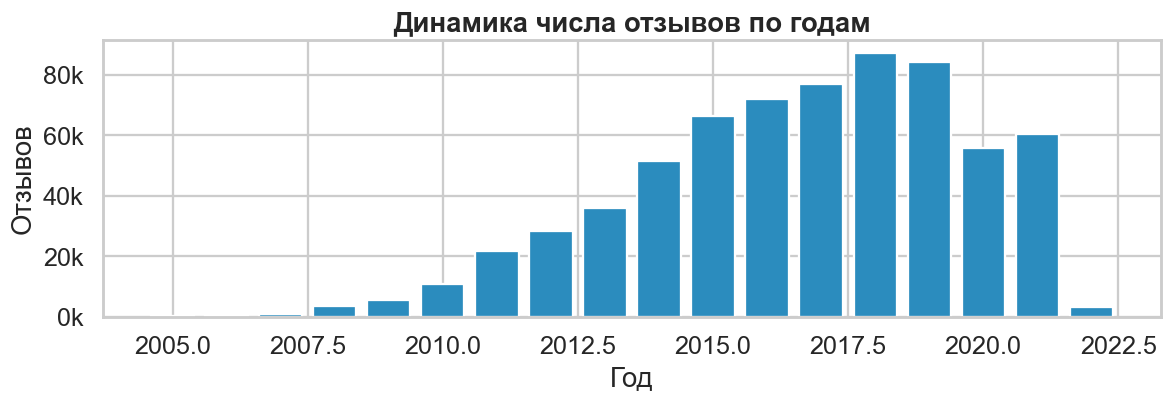

In [3]:
n_users_active = reviews["user_id"].nunique()
n_biz_active   = reviews["business_id"].nunique()
span = (reviews["date"].min(), reviews["date"].max())
overview = pd.DataFrame({
    "Метрика": ["Города среза", "Заведений (в срезе)", "Заведений с отзывами",
                "Уникальных юзеров", "Отзывов", "Типсов (без оценки)",
                "Период отзывов", "Средняя оценка"],
    "Значение": [CITY, f"{len(business):,}", f"{n_biz_active:,}",
                 f"{n_users_active:,}", f"{len(reviews):,}", f"{len(tips):,}",
                 f"{span[0].date()} — {span[1].date()}",
                 f"{reviews['stars'].mean():.2f} ★"],
})
display(overview)

# Динамика числа отзывов по годам
fig, ax = plt.subplots(figsize=(11,4))
by_year = reviews.set_index("date").resample("YE").size()
ax.bar(by_year.index.year, by_year.values, color="#2b8cbe")
ax.set_title("Динамика числа отзывов по годам")
ax.set_xlabel("Год"); ax.set_ylabel("Отзывов")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x/1000:.0f}k"))
savefig("01_reviews_per_year"); plt.show()

## 2. Табличный EDA — для Рекомендательной системы (Задача 1)

Рекомендатель учится по тройкам `(user, business, stars)`. Ключевые вопросы EDA:
распределение **таргета**, **активность** юзеров и **популярность** мест (длинные хвосты →
cold-start), **разреженность** матрицы взаимодействий (почему нужны эмбеддинги, а не one-hot),
и **смещения** оценок (почему в MF нужны bias-термы).

### 2.1. Распределение таргета `stars`
Сильный перекос вправо (много 5★) типичен для отзовиков — учитываем при выборе лосса и метрик.

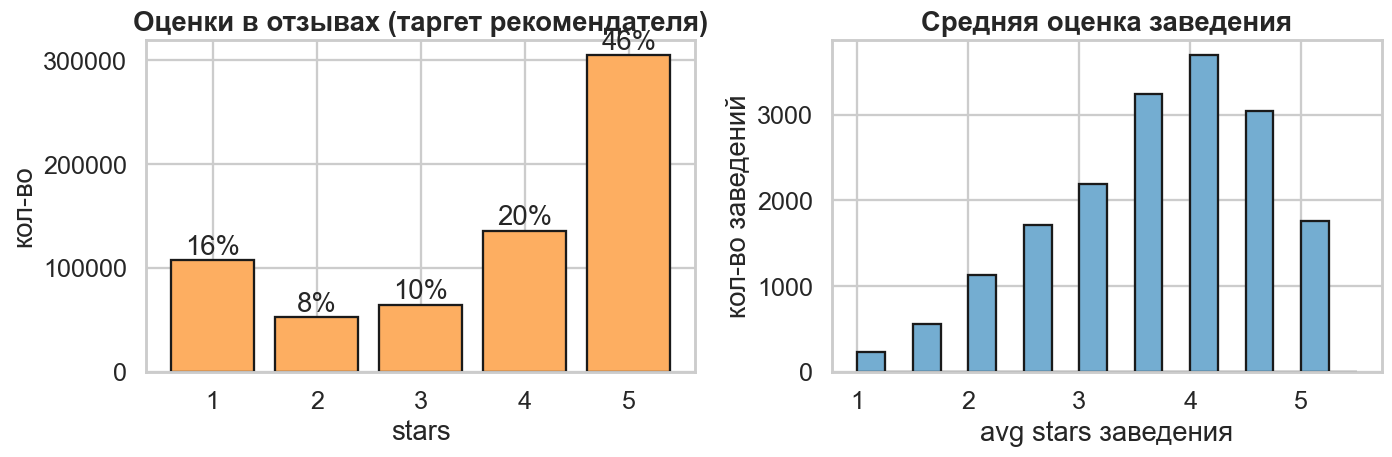

Доля 4-5★ среди отзывов: 66.2%
Глобальная средняя оценка (baseline для MF): 3.718


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13,4.5))
vc = reviews["stars"].value_counts().sort_index()
axes[0].bar(vc.index, vc.values, color="#fdae61", edgecolor="k")
axes[0].set_title("Оценки в отзывах (таргет рекомендателя)")
axes[0].set_xlabel("stars"); axes[0].set_ylabel("кол-во")
for x,y in zip(vc.index, vc.values):
    axes[0].text(x, y, f"{y/len(reviews)*100:.0f}%", ha="center", va="bottom")

axes[1].hist(business["stars"], bins=np.arange(1,5.6,0.25), color="#74add1", edgecolor="k")
axes[1].set_title("Средняя оценка заведения")
axes[1].set_xlabel("avg stars заведения"); axes[1].set_ylabel("кол-во заведений")
savefig("02_stars_distribution"); plt.show()

print("Доля 4-5★ среди отзывов: {:.1%}".format((reviews['stars']>=4).mean()))
print("Глобальная средняя оценка (baseline для MF): {:.3f}".format(reviews['stars'].mean()))

### 2.2. Активность пользователей и cold-start
Распределение «отзывов на юзера» — степенной хвост. Много юзеров с 1 отзывом → проблема холодного старта, которую эмбеддинги должны как-то покрывать.

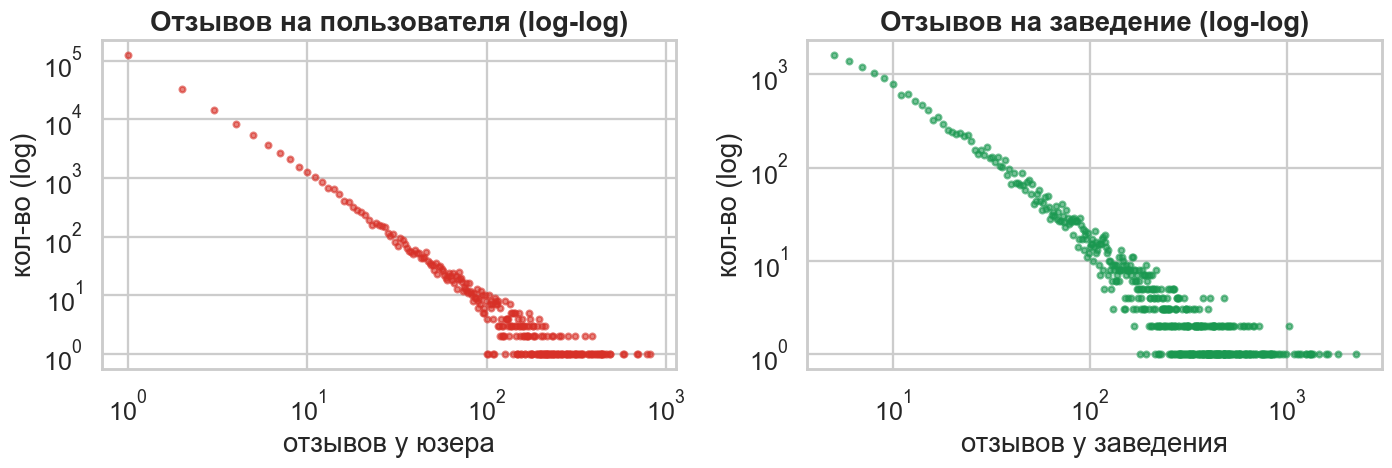

Юзеров ровно с 1 отзывом:   61.0%  (медиана отзывов/юзер = 1)
Заведений ровно с 1 отзывом: 0.0%  (медиана отзывов/место = 14)
ТОП-1% юзеров дают 24.4% всех отзывов


In [5]:
ru = reviews.groupby("user_id").size()
rb = reviews.groupby("business_id").size()

def loglog(ax, counts, color, title, xlab):
    vc = counts.value_counts().sort_index()
    ax.scatter(vc.index, vc.values, s=14, color=color, alpha=.6)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_title(title); ax.set_xlabel(xlab); ax.set_ylabel("кол-во (log)")

fig, axes = plt.subplots(1, 2, figsize=(13,4.6))
loglog(axes[0], ru, "#d73027", "Отзывов на пользователя (log-log)", "отзывов у юзера")
loglog(axes[1], rb, "#1a9850", "Отзывов на заведение (log-log)", "отзывов у заведения")
savefig("03_activity_powerlaw"); plt.show()

cold_u = (ru==1).mean(); cold_b = (rb==1).mean()
print(f"Юзеров ровно с 1 отзывом:   {cold_u:.1%}  (медиана отзывов/юзер = {ru.median():.0f})")
print(f"Заведений ровно с 1 отзывом: {cold_b:.1%}  (медиана отзывов/место = {rb.median():.0f})")
print(f"ТОП-1% юзеров дают {ru.sort_values().tail(int(len(ru)*0.01)).sum()/len(reviews):.1%} всех отзывов")

### 2.3. Разреженность матрицы взаимодействий
Главный аргумент за нейросеть с эмбеддингами: матрица `users × businesses` заполнена на доли процента — one-hot нереален, нужны плотные обучаемые векторы.

In [6]:
n_u, n_b, n_int = reviews["user_id"].nunique(), reviews["business_id"].nunique(), len(reviews)
density = n_int / (n_u * n_b)

# коэффициент Джини для популярности заведений (насколько неравномерно распределено внимание)
def gini(x):
    x = np.sort(np.asarray(x, float)); n = len(x)
    return (2*np.arange(1,n+1)-n-1).dot(x) / (n*x.sum())

print(f"Пользователей:            {n_u:,}")
print(f"Заведений:                {n_b:,}")
print(f"Взаимодействий (отзывов): {n_int:,}")
print(f"Плотность матрицы:        {density:.4%}  (заполнено {density*100:.3f}% ячеек)")
print(f"Разреженность:            {1-density:.4%}")
print(f"Gini популярности мест:   {gini(rb.values):.3f}  (0=равномерно, 1=всё внимание немногим)")
print(f"Gini активности юзеров:   {gini(ru.values):.3f}")

Пользователей:            209,098
Заведений:                17,556
Взаимодействий (отзывов): 664,751
Плотность матрицы:        0.0181%  (заполнено 0.018% ячеек)
Разреженность:            99.9819%
Gini популярности мест:   0.650  (0=равномерно, 1=всё внимание немногим)
Gini активности юзеров:   0.595


### 2.4. Смещения оценок (bias) — обоснование bias-термов в MF
Юзеры систематически добрее/строже среднего, заведения — лучше/хуже. Разброс этих смещений показывает, сколько «бесплатной» точности даст простой baseline `μ + b_user + b_item` ещё до эмбеддингов.

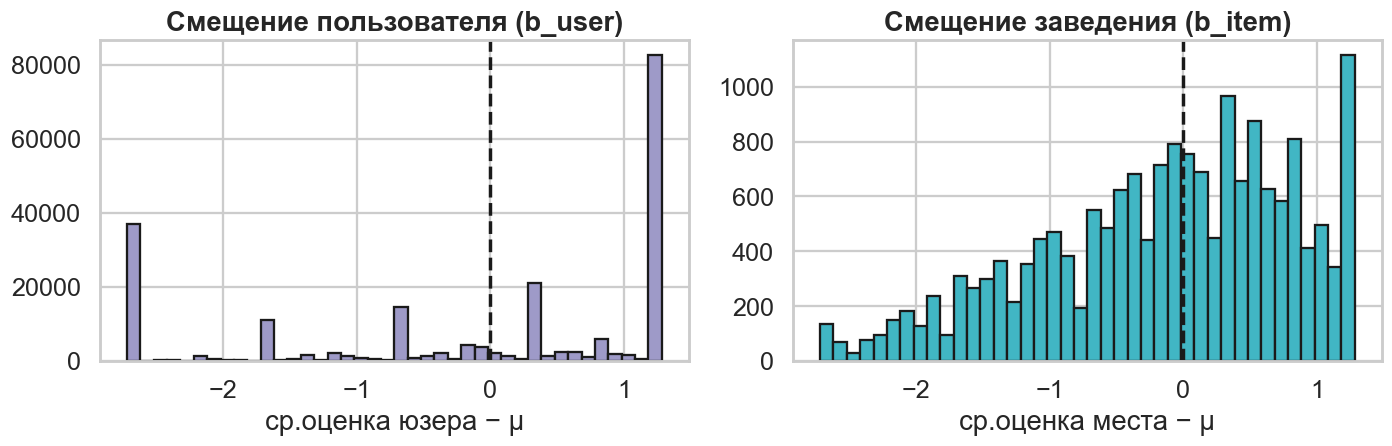

std смещения юзера:    1.518 ★
std смещения места:    0.949 ★
Чем больше эти std, тем сильнее baseline μ+b_u+b_i побьёт глобальное среднее.


In [7]:
mu = reviews["stars"].mean()
ub = reviews.groupby("user_id")["stars"].mean() - mu      # смещение юзера
bb = reviews.groupby("business_id")["stars"].mean() - mu  # смещение заведения

fig, axes = plt.subplots(1, 2, figsize=(13,4.4))
axes[0].hist(ub, bins=40, color="#9e9ac8", edgecolor="k")
axes[0].axvline(0, color="k", ls="--"); axes[0].set_title("Смещение пользователя (b_user)")
axes[0].set_xlabel("ср.оценка юзера − μ")
axes[1].hist(bb, bins=40, color="#41b6c4", edgecolor="k")
axes[1].axvline(0, color="k", ls="--"); axes[1].set_title("Смещение заведения (b_item)")
axes[1].set_xlabel("ср.оценка места − μ")
savefig("04_rating_bias"); plt.show()
print(f"std смещения юзера:    {ub.std():.3f} ★")
print(f"std смещения места:    {bb.std():.3f} ★")
print("Чем больше эти std, тем сильнее baseline μ+b_u+b_i побьёт глобальное среднее.")

### 2.5. Признаки заведений и связь с оценкой
Категории, ценовой диапазон и популярность — кандидаты во входные фичи рекомендателя. Смотрим, какие из них вообще связаны с оценкой.

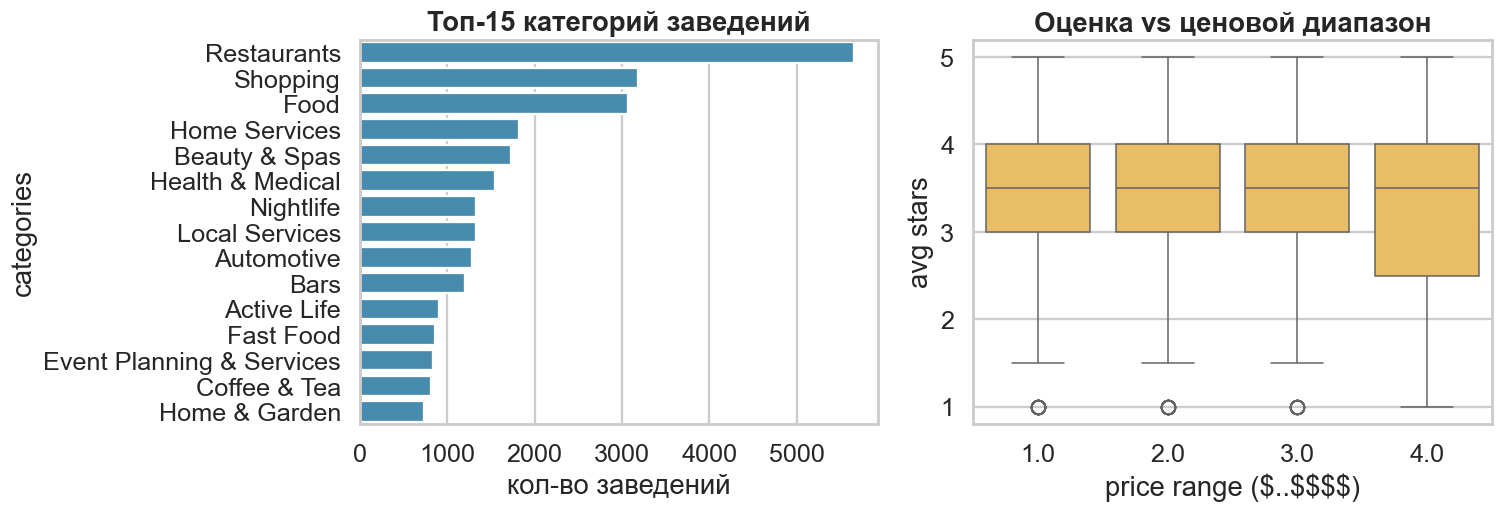

Корреляции с оценкой отзыва:
stars     1.000
useful   -0.116
funny    -0.065
cool      0.093
Name: stars, dtype: float64


In [8]:
# Топ категорий
cats = (business["categories"].dropna().str.split(", ").explode())
top_cats = cats.value_counts().head(15)
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.barplot(x=top_cats.values, y=top_cats.index, ax=axes[0], color="#3690c0")
axes[0].set_title("Топ-15 категорий заведений"); axes[0].set_xlabel("кол-во заведений")

# Ценовой диапазон vs средняя оценка (если распарсился)
if "price_range" in business.columns and business["price_range"].notna().any():
    pr = business.dropna(subset=["price_range"])
    sns.boxplot(data=pr, x="price_range", y="stars", ax=axes[1], color="#fec44f")
    axes[1].set_title("Оценка vs ценовой диапазон")
    axes[1].set_xlabel("price range ($..$$$$)"); axes[1].set_ylabel("avg stars")
else:
    axes[1].text(.5,.5,"price_range недоступен", ha="center"); axes[1].axis("off")
savefig("05_business_features"); plt.show()

# Корреляции числовых фич с оценкой отзыва
num = reviews[["stars","useful","funny","cool"]].copy()
print("Корреляции с оценкой отзыва:")
print(num.corr()["stars"].round(3))

## 3. Текстовый EDA — для Анализа отзывов (Задача 2)

Здесь готовим почву для NLP-моделей: оцениваем **длину** текста (выбор max_len для RNN/CNN/трансформера),
**баланс классов** тональности (нужен ли class weighting), **словарь** (размер эмбеддинг-слоя),
**отличительные слова** и **аспекты** (food/service/price — деливерабл аспектной тональности),
сигнал **расхождения текст↔оценка** (детектор фейков) и **язык** (фильтрация не-английского).

### 3.1. Длина отзывов
Определяет `max_len` и стоимость обучения. Длинные хвосты обрезаем по перцентилю, а не по максимуму.

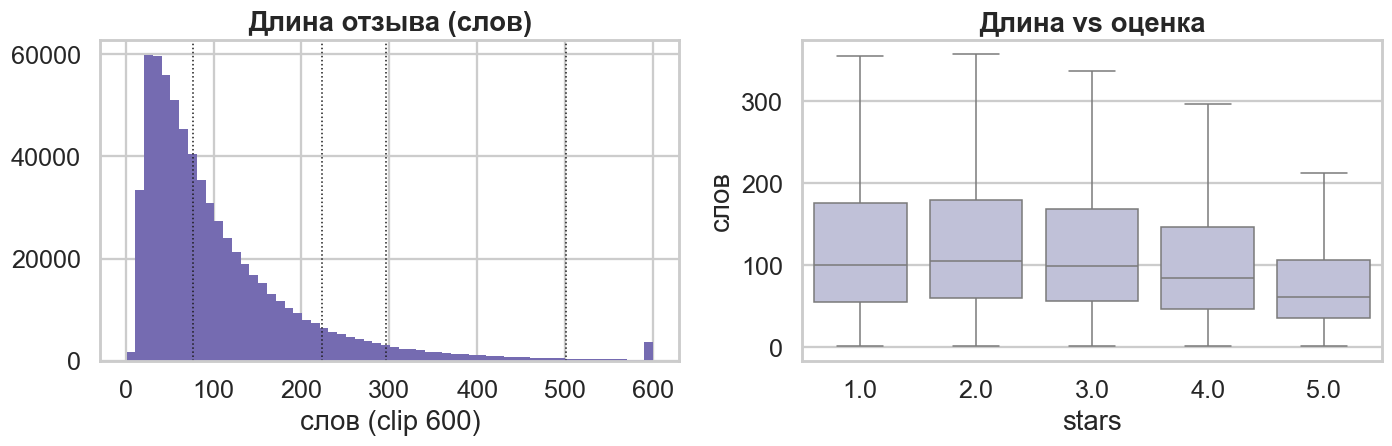

  50-й перцентиль длины: 77 слов
  90-й перцентиль длины: 223 слов
  95-й перцентиль длины: 296 слов
  99-й перцентиль длины: 501 слов
Рекомендуемый max_len (95-й перцентиль): ~296 токенов


In [9]:
reviews["n_chars"] = reviews["text"].str.len()
reviews["n_words"] = reviews["text"].str.split().map(len)

fig, axes = plt.subplots(1, 2, figsize=(13,4.4))
axes[0].hist(reviews["n_words"].clip(upper=600), bins=60, color="#756bb1", edgecolor="none")
axes[0].set_title("Длина отзыва (слов)"); axes[0].set_xlabel("слов (clip 600)")
for q in [0.5,0.9,0.95,0.99]:
    axes[0].axvline(reviews["n_words"].quantile(q), color="k", ls=":", lw=1)

sns.boxplot(data=reviews, x="stars", y="n_words", ax=axes[1], showfliers=False, color="#bcbddc")
axes[1].set_title("Длина vs оценка"); axes[1].set_xlabel("stars"); axes[1].set_ylabel("слов")
savefig("06_text_length"); plt.show()

for q in [0.5,0.9,0.95,0.99]:
    print(f"  {int(q*100)}-й перцентиль длины: {reviews['n_words'].quantile(q):.0f} слов")
print("Рекомендуемый max_len (95-й перцентиль): ~{:.0f} токенов".format(reviews['n_words'].quantile(0.95)))

### 3.2. Баланс классов тональности
Из `stars` строим метку тональности: 1–2★ → negative, 3★ → neutral, 4–5★ → positive. Дисбаланс — повод для class weights / стратификации.

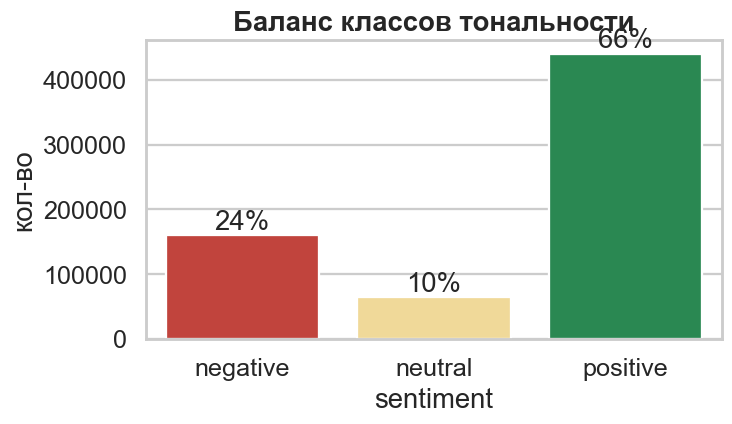

sentiment
negative    159966
neutral      64661
positive    440124
Name: count, dtype: int64
Дисбаланс (макс/мин): 6.8×  → нужны class weights / взвеш. метрики (macro-F1)


In [10]:
def to_sentiment(s):
    return np.where(s<=2,"negative", np.where(s==3,"neutral","positive"))
reviews["sentiment"] = to_sentiment(reviews["stars"])
bal = reviews["sentiment"].value_counts().reindex(["negative","neutral","positive"])

fig, ax = plt.subplots(figsize=(7,4.2))
sns.barplot(x=bal.index, y=bal.values, palette=["#d73027","#fee08b","#1a9850"], ax=ax)
for i,v in enumerate(bal.values): ax.text(i, v, f"{v/len(reviews):.0%}", ha="center", va="bottom")
ax.set_title("Баланс классов тональности"); ax.set_ylabel("кол-во")
savefig("07_sentiment_balance"); plt.show()
print(bal)
print(f"Дисбаланс (макс/мин): {bal.max()/bal.min():.1f}×  → нужны class weights / взвеш. метрики (macro-F1)")

### 3.3. Словарь и отличительные слова (weighted log-odds)
Размер словаря → размер эмбеддинг-слоя. Чтобы найти, какие слова реально *отличают* плохие отзывы от хороших, используем **weighted log-odds-ratio с информативным Дирихле-приором** (Monroe et al., 2008) — устойчивее обычной частоты/«облака слов» к редким и к ультра-частым словам.

Текстовый анализ на сэмпле: 150,000 отзывов из 664,751


Размер словаря (min_df=20): 13,456 слов


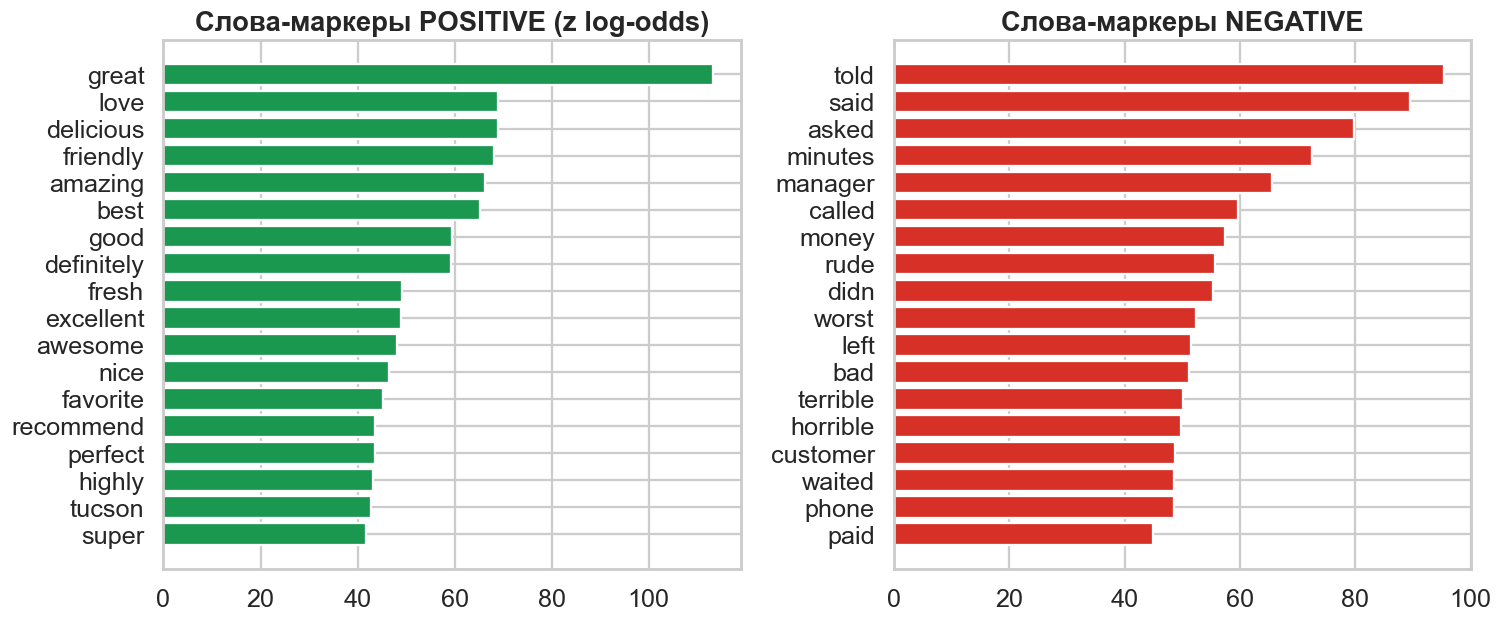

In [11]:
from sklearn.feature_extraction.text import CountVectorizer

# Текстовые операции — на стратифицированном сэмпле (скорость); размер логируем.
TEXT_SAMPLE = min(150_000, len(reviews))
samp = reviews.sample(TEXT_SAMPLE, random_state=42)
print(f"Текстовый анализ на сэмпле: {TEXT_SAMPLE:,} отзывов из {len(reviews):,}")

vec = CountVectorizer(stop_words="english", token_pattern=r"[a-zA-Z]{3,}", min_df=20)
X = vec.fit_transform(samp["text"].fillna(""))
vocab = np.array(vec.get_feature_names_out())
print(f"Размер словаря (min_df=20): {len(vocab):,} слов")

pos_mask = (samp["sentiment"]=="positive").values
neg_mask = (samp["sentiment"]=="negative").values
y_pos = np.asarray(X[pos_mask].sum(axis=0)).ravel()
y_neg = np.asarray(X[neg_mask].sum(axis=0)).ravel()
y_all = y_pos + y_neg

# Информативный Дирихле-приор из фонового корпуса (Monroe et al.)
a0, alpha = y_all.sum(), 0.01
a_w = alpha * y_all
np_, nn_ = y_pos.sum(), y_neg.sum()
def lo(y, n): return np.log((y + a_w) / (n + a0*alpha - y - a_w))
delta = lo(y_pos, np_) - lo(y_neg, nn_)
var = 1.0/(y_pos + a_w) + 1.0/(y_neg + a_w)
z = delta / np.sqrt(var)

order = np.argsort(z)
top_pos = vocab[order[::-1][:18]]; top_neg = vocab[order[:18]]
fig, axes = plt.subplots(1, 2, figsize=(14,6))
axes[0].barh(range(18), z[order[::-1][:18]], color="#1a9850"); axes[0].set_yticks(range(18))
axes[0].set_yticklabels(top_pos); axes[0].invert_yaxis(); axes[0].set_title("Слова-маркеры POSITIVE (z log-odds)")
axes[1].barh(range(18), -z[order[:18]], color="#d73027"); axes[1].set_yticks(range(18))
axes[1].set_yticklabels(top_neg); axes[1].invert_yaxis(); axes[1].set_title("Слова-маркеры NEGATIVE")
savefig("08_logodds_words"); plt.show()

### 3.4. Аспекты: food / service / price
Деливерабл — аспектная тональность. Проверяем, что аспектные термины реально присутствуют и по-разному ведут себя в хороших/плохих отзывах.

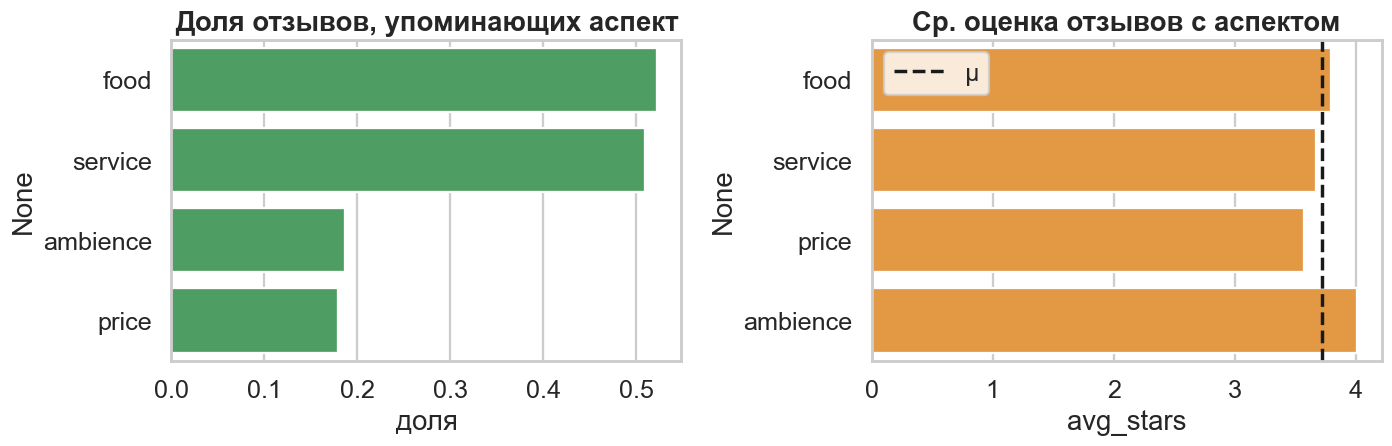

,avg_stars,share
food,3.791,0.523
service,3.669,0.510
price,3.571,0.179
ambience,4.011,0.187


In [12]:
ASPECTS = {
    "food":    r"\b(food|dish|meal|taste|flavor|menu|portion|delicious|pizza|burger|chicken)\b",
    "service": r"\b(service|staff|waiter|waitress|server|manager|rude|friendly|attentive)\b",
    "price":   r"\b(price|cheap|expensive|value|worth|overpriced|affordable|cost)\b",
    "ambience":r"\b(ambience|atmosphere|decor|music|cozy|noisy|clean|seating)\b",
}
asp = samp.copy()
for a, pat in ASPECTS.items():
    asp[a] = asp["text"].str.contains(pat, case=False, regex=True, na=False)

share = asp[list(ASPECTS)].mean().sort_values(ascending=False)
# средняя оценка отзывов, упоминающих аспект
by_asp = pd.DataFrame({a: [asp.loc[asp[a],"stars"].mean(), asp[a].mean()] for a in ASPECTS},
                      index=["avg_stars","share"]).T
fig, axes = plt.subplots(1, 2, figsize=(13,4.4))
sns.barplot(x=share.values, y=share.index, ax=axes[0], color="#41ab5d")
axes[0].set_title("Доля отзывов, упоминающих аспект"); axes[0].set_xlabel("доля")
sns.barplot(x=by_asp["avg_stars"], y=by_asp.index, ax=axes[1], color="#fe9929")
axes[1].axvline(reviews["stars"].mean(), color="k", ls="--", label="μ")
axes[1].set_title("Ср. оценка отзывов с аспектом"); axes[1].legend()
savefig("09_aspects"); plt.show()
display(by_asp.round(3))

### 3.5. Сигнал расхождения «текст ↔ оценка» (детектор фейков/накрутки)
Простой лексиконный сентимент-скор текста сравниваем со звёздами. Сильные расхождения (злой текст при 5★ и наоборот) — кандидаты в фейки. EDA показывает, что сигнал есть и его стоит моделировать.

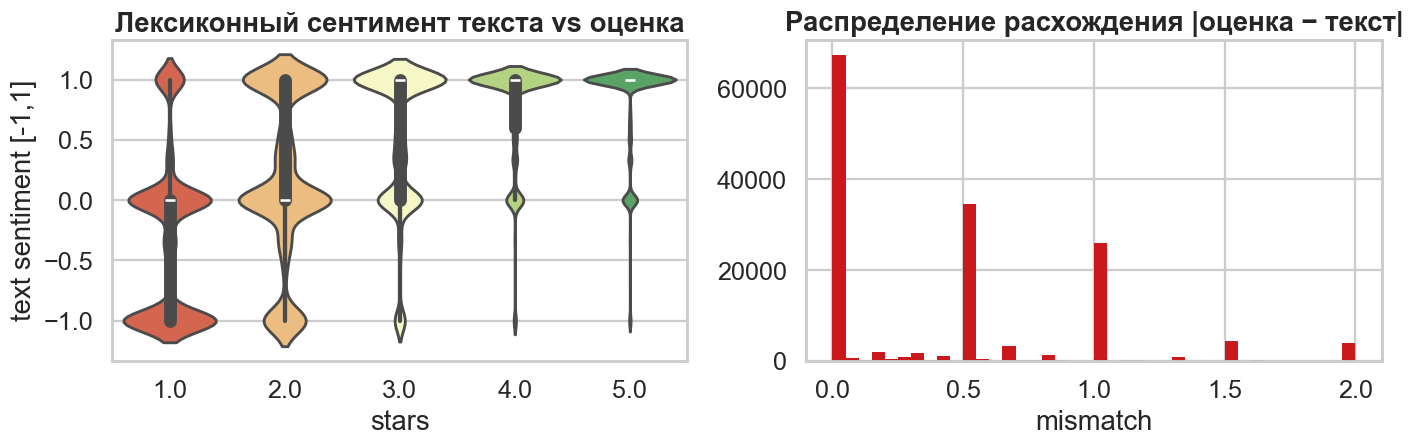

Примеры сильного расхождения (потенц. фейк / накрутка):
  ★1 | text_sent=+1.00 | My first time here at the Macaroni Grill and It was truly an unpleasant experience. I went within the first hour of them...
  ★1 | text_sent=+1.00 | Ginger beef was average. Orange chicken below average. Egg rolls below average. Chinese mushroom witty tofu was fantasti...
  ★1 | text_sent=+1.00 | Atrocious -- the owner charges more than what's on the sign and hopes you won't notice. Pizza was like cardboard and had...

Доля отзывов с сильным расхождением (>1.0): 6.5%


In [13]:
POS_LEX = set("great good love amazing best delicious excellent perfect friendly awesome wonderful fantastic".split())
NEG_LEX = set("bad worst terrible awful rude horrible disgusting slow dirty never overpriced disappointing".split())
def lex_score(t):
    w = re.findall(r"[a-z]+", str(t).lower())
    p = sum(x in POS_LEX for x in w); n = sum(x in NEG_LEX for x in w)
    return (p-n)/max(p+n,1)
samp = samp.assign(lex=samp["text"].map(lex_score))
samp["stars_norm"] = (samp["stars"]-3)/2          # в шкалу [-1,1]
samp["mismatch"] = (samp["stars_norm"]-samp["lex"]).abs()

fig, axes = plt.subplots(1, 2, figsize=(13,4.4))
sns.violinplot(data=samp, x="stars", y="lex", ax=axes[0], palette="RdYlGn")
axes[0].set_title("Лексиконный сентимент текста vs оценка"); axes[0].set_ylabel("text sentiment [-1,1]")
axes[1].hist(samp["mismatch"], bins=40, color="#cb181d", edgecolor="none")
axes[1].set_title("Распределение расхождения |оценка − текст|"); axes[1].set_xlabel("mismatch")
savefig("10_text_star_mismatch"); plt.show()

flag = samp.sort_values("mismatch", ascending=False).head(3)
print("Примеры сильного расхождения (потенц. фейк / накрутка):")
for _, r in flag.iterrows():
    print(f"  ★{int(r['stars'])} | text_sent={r['lex']:+.2f} | {str(r['text'])[:120]}...")
print(f"\nДоля отзывов с сильным расхождением (>1.0): {(samp['mismatch']>1.0).mean():.1%}")

### 3.6. Язык отзывов
Модели обучаем на английском; не-английские отзывы надо отфильтровать или обрабатывать отдельно. Оцениваем долю на сэмпле.

In [14]:
import langid
lang_samp = samp.sample(min(4000, len(samp)), random_state=1)
langs = lang_samp["text"].fillna("").map(lambda t: langid.classify(t[:400])[0])
share_lang = langs.value_counts(normalize=True).head(6)
print("Доли языков (сэмпл 4k):")
print((share_lang*100).round(2).astype(str) + " %")
print(f"\nДоля английского: {(langs=='en').mean():.1%}  → остальное фильтруем на препроцессинге NLP")

Доли языков (сэмпл 4k):
text
en    99.95 %
af     0.02 %
es     0.02 %
Name: proportion, dtype: object

Доля английского: 100.0%  → остальное фильтруем на препроцессинге NLP


### 3.7. Типсы (tip.json) — текст без оценки
У типсов **нет** рейтинга — это целевой объект для inference обученной моделью (применение «оценка текста без звёзд»). Сравниваем их длину с отзывами.

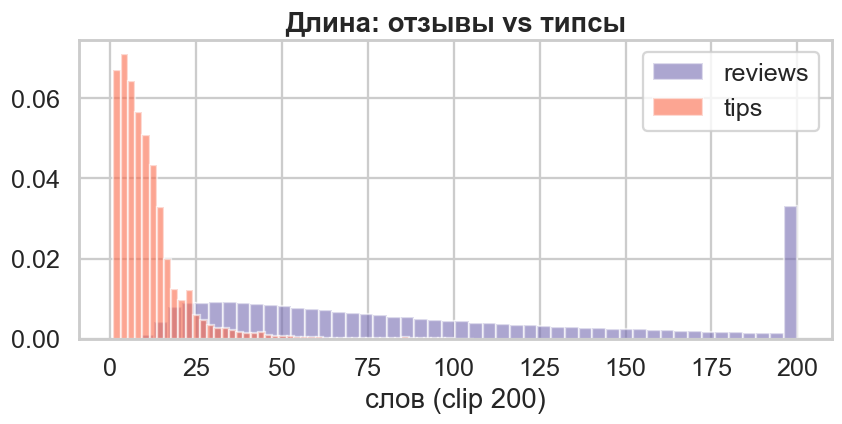

Типсов без оценки: 91,803 | медиана длины 9 слов (у отзывов 77)


In [15]:
if len(tips):
    tips["n_words"] = tips["text"].str.split().map(len)
    fig, ax = plt.subplots(figsize=(8,4.2))
    ax.hist(reviews["n_words"].clip(upper=200), bins=50, alpha=.6, density=True, label="reviews", color="#756bb1")
    ax.hist(tips["n_words"].clip(upper=200), bins=50, alpha=.6, density=True, label="tips", color="#fb6a4a")
    ax.legend(); ax.set_title("Длина: отзывы vs типсы"); ax.set_xlabel("слов (clip 200)")
    savefig("11_tips_vs_reviews"); plt.show()
    print(f"Типсов без оценки: {len(tips):,} | медиана длины {tips['n_words'].median():.0f} слов "
          f"(у отзывов {reviews['n_words'].median():.0f})")
else:
    print("tips.parquet пуст — пропускаем")

## 4. Качество данных
Пропуски, дубликаты, повторные визиты и «удалённые» пользователи — то, что чинится на препроцессинге до обучения.

In [16]:
print("Пропуски по таблицам (доля):")
for name, df in [("business",business),("reviews",reviews),("users",users)]:
    miss = df.isna().mean()
    miss = miss[miss>0]
    print(f"  {name}: " + (", ".join(f"{c}={v:.1%}" for c,v in miss.items()) if len(miss) else "нет пропусков"))

dup_rev = reviews.duplicated(subset=["review_id"]).sum()
dup_pair = reviews.duplicated(subset=["user_id","business_id"]).sum()
missing_users = (~reviews["user_id"].isin(users["user_id"])).mean()
print(f"\nДубликаты review_id:                 {dup_rev:,}")
print(f"Повторные пары (user,business):      {dup_pair:,} ({dup_pair/len(reviews):.1%}) — повторные визиты")
print(f"Отзывы от 'удалённых' юзеров (нет в users.json): {missing_users:.1%}")

Пропуски по таблицам (доля):
  business: categories=0.1%, price_range=44.1%
  reviews: нет пропусков
  users: нет пропусков



Дубликаты review_id:                 0
Повторные пары (user,business):      26,680 (4.0%) — повторные визиты
Отзывы от 'удалённых' юзеров (нет в users.json): 0.0%


## 5. Выводы EDA → решения по моделированию

Финальная сводка: что именно EDA говорит для каждой из двух задач. Числа берутся из ячеек выше.

In [17]:
print("="*68)
print(f"YELP EDA · срез: {CITY}")
print("="*68)
print("\n— ЗАДАЧА 1 · РЕКОМЕНДАТЕЛЬ (табличные, FCNN) —")
print(f"• Матрица user×item заполнена на {density:.3%} → one-hot невозможен,")
print(f"  обоснованы ОБУЧАЕМЫЕ ЭМБЕДДИНГИ (MF→MLP→NeuMF).")
print(f"• {cold_u:.0%} юзеров и {cold_b:.0%} мест имеют 1 отзыв → cold-start:")
print(f"  добавляем контентные фичи (категории, price, активность) поверх ID-эмбеддингов.")
print(f"• std смещений: юзер={ub.std():.2f}, место={bb.std():.2f} → bias-термы μ+b_u+b_i")
print(f"  как сильный baseline; целевая метрика RMSE/MAE на удержанных парах.")
print(f"• Перекос к 4-5★ ({(reviews['stars']>=4).mean():.0%}) → MAE информативнее accuracy.")
print("\n— ЗАДАЧА 2 · АНАЛИЗ ОТЗЫВОВ (текст, RNN/CNN/Transformer) —")
print(f"• max_len ≈ {reviews['n_words'].quantile(0.95):.0f} токенов (95-й перц.) — обрезка по хвосту.")
print(f"• Дисбаланс тональности {bal.max()/bal.min():.1f}× → class weights + macro-F1.")
print(f"• Словарь ~{len(vocab):,} слов (min_df=20) → размер эмбеддинг-слоя для BiLSTM/TextCNN.")
print(f"• Аспекты food/service/price реально присутствуют → возможна аспектная тональность.")
print(f"• {(samp['mismatch']>1.0).mean():.0%} отзывов с расхождением текст↔оценка → детектор фейков.")
print(f"• Английский ≈ {(langs=='en').mean():.0%} → фильтрация языка на препроцессинге.")
print(f"• {len(tips):,} типсов без оценки → объект для inference обученной моделью.")
print("="*68)

YELP EDA · срез: Tucson, AZ + St Petersburg, FL + Edmonton, AB

— ЗАДАЧА 1 · РЕКОМЕНДАТЕЛЬ (табличные, FCNN) —
• Матрица user×item заполнена на 0.018% → one-hot невозможен,
  обоснованы ОБУЧАЕМЫЕ ЭМБЕДДИНГИ (MF→MLP→NeuMF).
• 61% юзеров и 0% мест имеют 1 отзыв → cold-start:
  добавляем контентные фичи (категории, price, активность) поверх ID-эмбеддингов.
• std смещений: юзер=1.52, место=0.95 → bias-термы μ+b_u+b_i
  как сильный baseline; целевая метрика RMSE/MAE на удержанных парах.
• Перекос к 4-5★ (66%) → MAE информативнее accuracy.

— ЗАДАЧА 2 · АНАЛИЗ ОТЗЫВОВ (текст, RNN/CNN/Transformer) —
• max_len ≈ 296 токенов (95-й перц.) — обрезка по хвосту.
• Дисбаланс тональности 6.8× → class weights + macro-F1.
• Словарь ~13,456 слов (min_df=20) → размер эмбеддинг-слоя для BiLSTM/TextCNN.
• Аспекты food/service/price реально присутствуют → возможна аспектная тональность.
• 7% отзывов с расхождением текст↔оценка → детектор фейков.
• Английский ≈ 100% → фильтрация языка на препроцессинге.
• 91

### Краткие выводы для презентации (бизнес-язык)

**Рекомендатель.** Внимание на Yelp распределено крайне неравномерно (Gini популярности высок,
большинство мест и юзеров — с единичными отзывами). Поэтому персонализация не может опираться на
«популярное вообще» — нужны индивидуальные векторы вкусов (эмбеддинги). Простые смещения «добрый
юзер / хорошее место» уже дают ощутимую точность — это честный baseline, который должны побить
нейросети.

**Анализ отзывов.** Оценка в звёздах огрубляет содержание: длинные отзывы одинаково встречаются у
довольных и недовольных, а упоминания *сервиса* в среднем тянут оценку вниз сильнее, чем упоминания
*еды*. Это и есть ценность аспектной тональности. Заметная доля отзывов демонстрирует расхождение
между тоном текста и звёздами — основа для детектора накруток. Наконец, тысячи типсов вообще без
оценки ждут, когда обученная модель проставит им тональность.